# Notebook 3 — A Full 1D Finite Element Solver in Pure Python

In this notebook, we solve the problem

$$
-u''(x)=1, \quad x\in[0,1], \qquad u(0)=u(1)=0
$$

using linear finite elements.

This notebook combines the ideas from the first two notebooks:

- mesh
- hat functions
- local stiffness matrix
- local force vector
- assembly
- boundary conditions
- solution of the linear system

## 1. Exact solution

For this simple problem, the exact solution is

$$
u(x)=\frac{1}{2}x(1-x).
$$

This will let us compare the finite element solution with the true answer.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

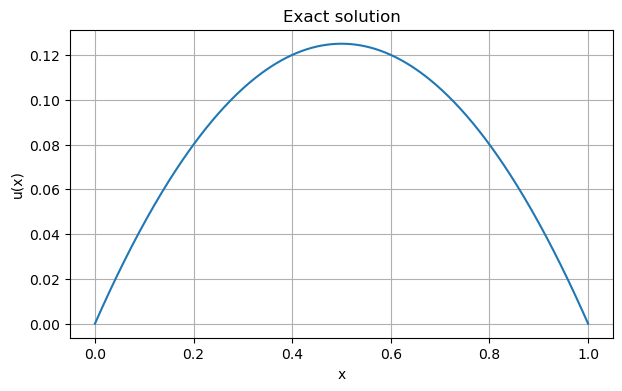

In [2]:
def u_exact(x):
    return 0.5 * x * (1.0 - x)

xx = np.linspace(0, 1, 400)
plt.figure(figsize=(7, 4))
plt.plot(xx, u_exact(xx))
plt.xlabel("x")
plt.ylabel("u(x)")
plt.title("Exact solution")
plt.grid(True)
plt.show()

## 2. Build the mesh

We divide the interval $[0,1]$ into equal elements.

In [3]:
L = 1.0
n_elements = 8
n_nodes = n_elements + 1

x_nodes = np.linspace(0.0, L, n_nodes)
h = x_nodes[1] - x_nodes[0]

print("Nodes:")
print(x_nodes)
print("\nElement length h =", h)

Nodes:
[0.    0.125 0.25  0.375 0.5   0.625 0.75  0.875 1.   ]

Element length h = 0.125


## 3. Element matrix and element vector

For linear elements, the local stiffness matrix is

$$
K^{(e)} = \frac{1}{h}
\begin{bmatrix}
1 & -1 \\
-1 & 1
\end{bmatrix}.
$$

For the right-hand side $f(x)=1$, the local force vector is

$$
F^{(e)} = \frac{h}{2}
\begin{bmatrix}
1 \\
1
\end{bmatrix}.
$$

In [4]:
Ke = (1.0 / h) * np.array([[1.0, -1.0],
                           [-1.0, 1.0]])

Fe = (h / 2.0) * np.array([1.0, 1.0])

print("Element stiffness matrix Ke:")
print(Ke)

print("\nElement force vector Fe:")
print(Fe)

Element stiffness matrix Ke:
[[ 8. -8.]
 [-8.  8.]]

Element force vector Fe:
[0.0625 0.0625]


## 4. Assemble the global system

We now add each element contribution to the global matrix and vector.

In [5]:
K = np.zeros((n_nodes, n_nodes))
F = np.zeros(n_nodes)

for e in range(n_elements):
    nodes = [e, e + 1]
    K[np.ix_(nodes, nodes)] += Ke
    F[nodes] += Fe

print("Global stiffness matrix K:")
print(K)

print("\nGlobal force vector F:")
print(F)

Global stiffness matrix K:
[[ 8. -8.  0.  0.  0.  0.  0.  0.  0.]
 [-8. 16. -8.  0.  0.  0.  0.  0.  0.]
 [ 0. -8. 16. -8.  0.  0.  0.  0.  0.]
 [ 0.  0. -8. 16. -8.  0.  0.  0.  0.]
 [ 0.  0.  0. -8. 16. -8.  0.  0.  0.]
 [ 0.  0.  0.  0. -8. 16. -8.  0.  0.]
 [ 0.  0.  0.  0.  0. -8. 16. -8.  0.]
 [ 0.  0.  0.  0.  0.  0. -8. 16. -8.]
 [ 0.  0.  0.  0.  0.  0.  0. -8.  8.]]

Global force vector F:
[0.0625 0.125  0.125  0.125  0.125  0.125  0.125  0.125  0.0625]


## 5. Apply boundary conditions

The boundary conditions are

$$
u(0)=0, \qquad u(1)=0.
$$

These values are known, so only the interior unknowns must be solved for.

In [6]:
fixed = [0, n_nodes - 1]
free = np.setdiff1d(np.arange(n_nodes), fixed)

u = np.zeros(n_nodes)
u[free] = np.linalg.solve(K[np.ix_(free, free)], F[free])

print("Nodal FEM solution:")
print(u)

Nodal FEM solution:
[0.        0.0546875 0.09375   0.1171875 0.125     0.1171875 0.09375
 0.0546875 0.       ]


## 6. Compare with the exact solution

Let us compare the nodal FEM values with the exact solution.

In [7]:
u_ex_nodes = u_exact(x_nodes)
error_nodes = u - u_ex_nodes

print("Exact nodal values:")
print(u_ex_nodes)

print("\nNodal error:")
print(error_nodes)

print("\nMaximum absolute nodal error:", np.max(np.abs(error_nodes)))

Exact nodal values:
[0.        0.0546875 0.09375   0.1171875 0.125     0.1171875 0.09375
 0.0546875 0.       ]

Nodal error:
[ 0.00000000e+00  0.00000000e+00  0.00000000e+00 -1.38777878e-17
  0.00000000e+00  0.00000000e+00  1.38777878e-17  0.00000000e+00
  0.00000000e+00]

Maximum absolute nodal error: 1.3877787807814457e-17


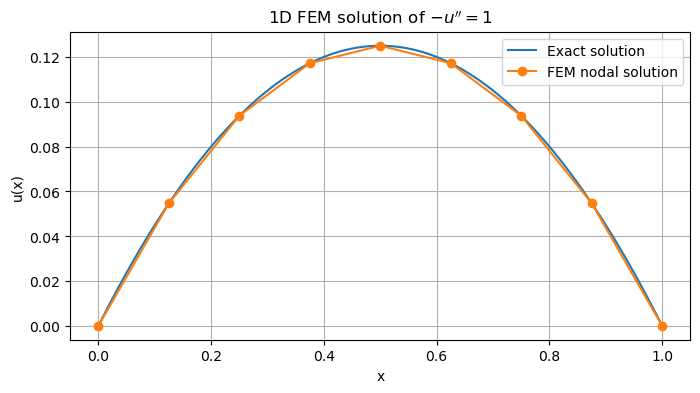

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(xx, u_exact(xx), label="Exact solution")
plt.plot(x_nodes, u, "o-", label="FEM nodal solution")
plt.xlabel("x")
plt.ylabel("u(x)")
plt.title("1D FEM solution of $-u'' = 1$")
plt.grid(True)
plt.legend()
plt.show()

## 7. Reconstruct the finite element solution between nodes

The FEM solution is not only defined at nodes.  
Between nodes, it is piecewise linear.

We can reconstruct it using the hat functions.

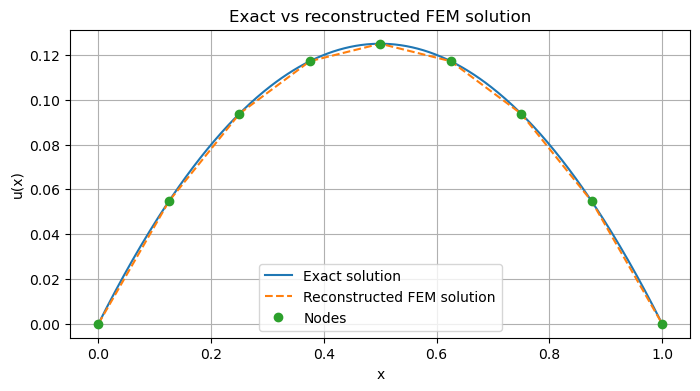

In [9]:
def hat_function(x, nodes, i):
    x = np.asarray(x)
    phi = np.zeros_like(x, dtype=float)

    if i > 0:
        xl = nodes[i - 1]
        xm = nodes[i]
        mask = (x >= xl) & (x <= xm)
        phi[mask] = (x[mask] - xl) / (xm - xl)

    if i < len(nodes) - 1:
        xm = nodes[i]
        xr = nodes[i + 1]
        mask = (x >= xm) & (x <= xr)
        phi[mask] = (xr - x[mask]) / (xr - xm)

    return phi

u_fem = np.zeros_like(xx)
for i in range(n_nodes):
    u_fem += u[i] * hat_function(xx, x_nodes, i)

plt.figure(figsize=(8, 4))
plt.plot(xx, u_exact(xx), label="Exact solution")
plt.plot(xx, u_fem, "--", label="Reconstructed FEM solution")
plt.plot(x_nodes, u, "o", label="Nodes")
plt.xlabel("x")
plt.ylabel("u(x)")
plt.title("Exact vs reconstructed FEM solution")
plt.grid(True)
plt.legend()
plt.show()

## 8. Error and mesh refinement

A key idea in numerical methods is that the solution improves when the mesh is refined.

In [10]:
def fem_1d_poisson(n_elements):
    L = 1.0
    n_nodes = n_elements + 1
    x_nodes = np.linspace(0.0, L, n_nodes)
    h = x_nodes[1] - x_nodes[0]

    Ke = (1.0 / h) * np.array([[1.0, -1.0],
                               [-1.0, 1.0]])
    Fe = (h / 2.0) * np.array([1.0, 1.0])

    K = np.zeros((n_nodes, n_nodes))
    F = np.zeros(n_nodes)

    for e in range(n_elements):
        nodes = [e, e + 1]
        K[np.ix_(nodes, nodes)] += Ke
        F[nodes] += Fe

    fixed = [0, n_nodes - 1]
    free = np.setdiff1d(np.arange(n_nodes), fixed)

    u = np.zeros(n_nodes)
    u[free] = np.linalg.solve(K[np.ix_(free, free)], F[free])

    return x_nodes, u

mesh_sizes = [4, 8, 16, 32]
errors = []

for ne in mesh_sizes:
    x_nodes, u_num = fem_1d_poisson(ne)
    err = np.max(np.abs(u_num - u_exact(x_nodes)))
    errors.append(err)

for ne, err in zip(mesh_sizes, errors):
    print(f"n_elements = {ne:2d}, max nodal error = {err:.6e}")

n_elements =  4, max nodal error = 1.387779e-17
n_elements =  8, max nodal error = 1.387779e-17
n_elements = 16, max nodal error = 1.387779e-17
n_elements = 32, max nodal error = 3.885781e-16


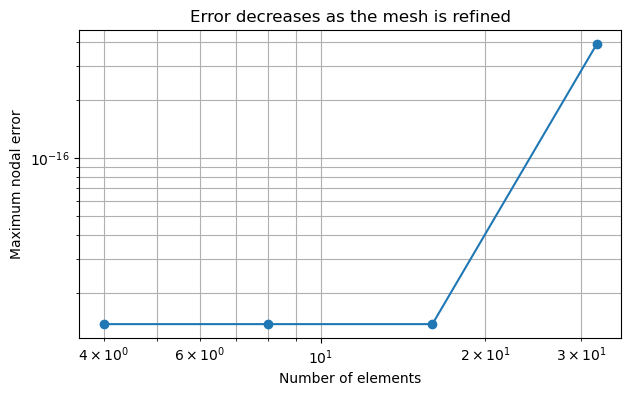

In [11]:
plt.figure(figsize=(7, 4))
plt.loglog(mesh_sizes, errors, "o-")
plt.xlabel("Number of elements")
plt.ylabel("Maximum nodal error")
plt.title("Error decreases as the mesh is refined")
plt.grid(True, which="both")
plt.show()

## 9. Main ideas to remember

This notebook shows the full FEM workflow:

1. define the mesh
2. compute the element matrix and vector
3. assemble the global system
4. impose boundary conditions
5. solve for the nodal values
6. reconstruct the approximate solution

Even though this is a simple 1D example, the same structure is used in more advanced finite element codes.

## Suggested exercises

1. Replace the right-hand side $f(x)=1$ by another function, for example $f(x)=x$.
2. Change the number of elements and observe the solution.
3. Print the reduced matrix after boundary conditions are applied.
4. Compare this FEM solution with a finite-difference solution of the same problem.

## Summary

You have now built a complete 1D finite element solver in pure Python.

That is the essential starting point for understanding larger FEM libraries later.